In [48]:
import sys
print(sys.executable)

c:\Users\Hp\MutualFundAnalytics\venv\Scripts\python.exe


In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [50]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
fund = pd.read_csv("../data/processed/clean_fund_master.csv")
aum = pd.read_csv("../data/processed/clean_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/clean_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/clean_category_inflows.csv")
folio = pd.read_csv("../data/processed/clean_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")
investor = pd.read_csv("../data/processed/clean_investor_transactions.csv")
portfolio = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/processed/clean_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [51]:
datasets = {
    "NAV": nav,
    "Fund Master": fund,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Investor": investor,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name:<15} {df.shape}")

NAV             (46000, 3)
Fund Master     (40, 15)
AUM             (90, 5)
SIP             (48, 6)
Category        (144, 3)
Folio           (21, 6)
Performance     (40, 19)
Investor        (32778, 13)
Portfolio       (322, 8)
Benchmark       (8050, 3)


In [52]:
nav["date"] = pd.to_datetime(nav["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(sip["month"])

category["month"] = pd.to_datetime(category["month"])

folio["month"] = pd.to_datetime(folio["month"])

investor["transaction_date"] = pd.to_datetime(investor["transaction_date"])

portfolio["portfolio_date"] = pd.to_datetime(portfolio["portfolio_date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Date conversion completed.")

Date conversion completed.


In [53]:
nav_fund = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_fund.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [54]:
print("Number of Funds:", nav_fund["scheme_name"].nunique())

Number of Funds: 40


In [55]:
fig = px.line(
    nav_fund,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme_name": "Scheme"
    }
)

fig.update_layout(
    width=1200,
    height=650,
    template="plotly_white"
)

fig.show()

In [56]:
fig = px.line(
    nav_fund,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.update_layout(
    width=1200,
    height=650,
    template="plotly_white"
)

fig.show()

In [57]:
import os

os.makedirs("../charts", exist_ok=True)

print("Charts folder created successfully!")

Charts folder created successfully!


In [58]:
fig.write_html("../charts/nav_trend_all_funds.html") 

In [59]:
fig.write_html("../charts/nav_trend_all_funds.html")

print("Chart saved successfully!")

Chart saved successfully!


In [60]:
import kaleido
print("Kaleido installed successfully!")

Kaleido installed successfully!


In [61]:
import kaleido

print("Kaleido imported successfully!")

Kaleido imported successfully!


In [62]:
import plotly

print(plotly.__version__)

6.8.0


In [63]:
import os

os.makedirs("../charts", exist_ok=True)

fig.write_html("../charts/nav_trend_all_funds.html")
fig.write_image("../charts/nav_trend_all_funds.png")

print("Charts saved successfully!")

Charts saved successfully!


In [64]:
## 2. NAV Trend Analysis

### Objective Analyze the daily Net Asset Value (NAV) trends of mutual fund schemes from 2022 to 2026.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [66]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
fund = pd.read_csv("../data/processed/clean_fund_master.csv")
aum = pd.read_csv("../data/processed/clean_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/clean_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/clean_category_inflows.csv")
folio = pd.read_csv("../data/processed/clean_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")
investor = pd.read_csv("../data/processed/clean_investor_transactions.csv")
portfolio = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/processed/clean_benchmark_indices.csv")

print("All datasets loaded")

All datasets loaded


In [67]:
nav["date"] = pd.to_datetime(nav["date"])
aum["date"] = pd.to_datetime(aum["date"])
sip["month"] = pd.to_datetime(sip["month"])
category["month"] = pd.to_datetime(category["month"])
folio["month"] = pd.to_datetime(folio["month"])
investor["transaction_date"] = pd.to_datetime(investor["transaction_date"])
portfolio["portfolio_date"] = pd.to_datetime(portfolio["portfolio_date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [68]:
nav_fund = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [69]:
nav_fund["date"] = pd.to_datetime(nav_fund["date"])

In [70]:
sample_fund = nav_fund["scheme_name"].iloc[0]

df_sample = nav_fund[nav_fund["scheme_name"] == sample_fund]
df_sample.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


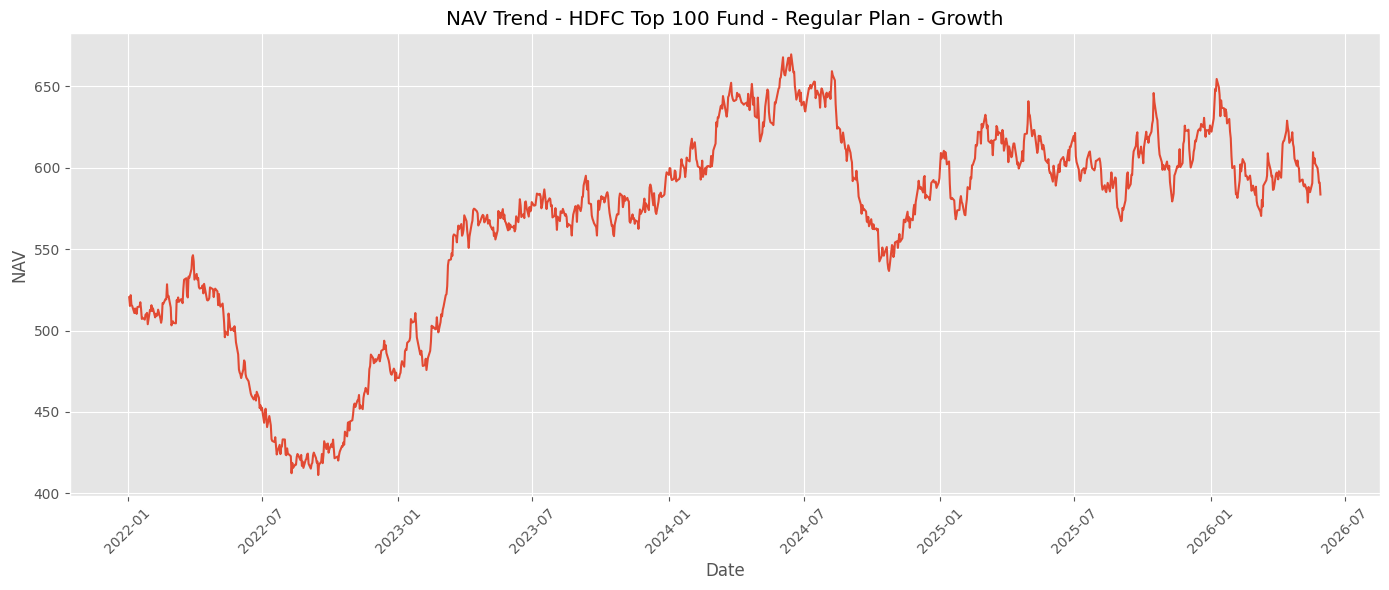

In [71]:
plt.figure(figsize=(14,6))

plt.plot(df_sample["date"], df_sample["nav"])

plt.title(f"NAV Trend - {sample_fund}")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

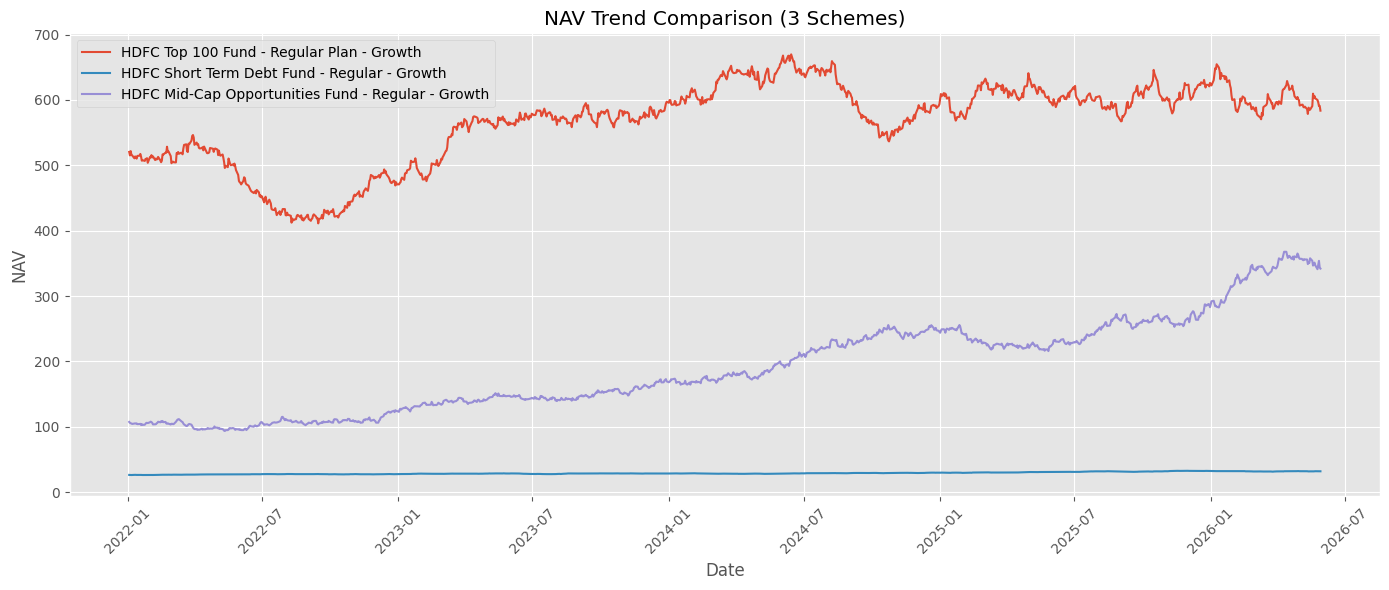

In [72]:
top_funds = nav_fund["scheme_name"].unique()[:3]

plt.figure(figsize=(14,6))

for f in top_funds:
    temp = nav_fund[nav_fund["scheme_name"] == f]
    plt.plot(temp["date"], temp["nav"], label=f)

plt.legend()
plt.title("NAV Trend Comparison (3 Schemes)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [73]:
nav_fund["nav_normalized"] = nav_fund.groupby("scheme_name")["nav"].transform(
    lambda x: x / x.iloc[0] * 100
)

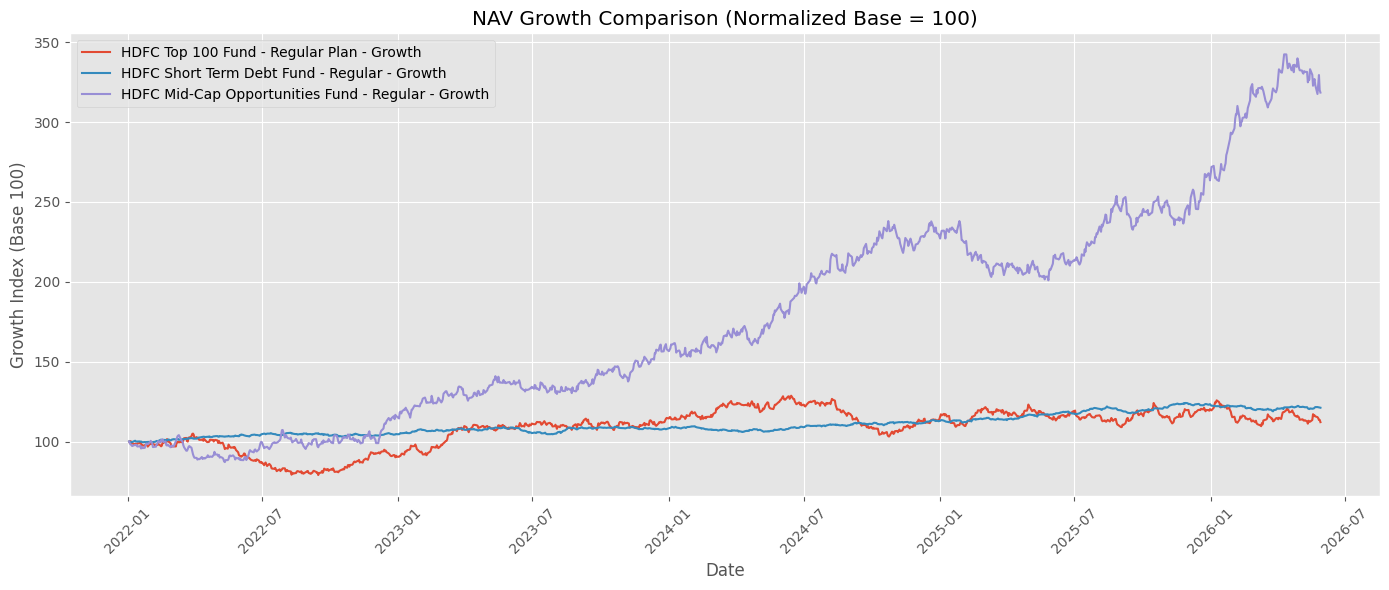

In [74]:
plt.figure(figsize=(14,6))

for f in nav_fund["scheme_name"].unique()[:3]:
    temp = nav_fund[nav_fund["scheme_name"] == f]
    plt.plot(temp["date"], temp["nav_normalized"], label=f)

plt.title("NAV Growth Comparison (Normalized Base = 100)")
plt.xlabel("Date")
plt.ylabel("Growth Index (Base 100)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [75]:
aum.head()


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [76]:
aum["date"] = pd.to_datetime(aum["date"])

In [77]:
aum_grouped = aum.groupby(["date", "fund_house"])["aum_crore"].sum().reset_index()

In [78]:
import plotly.express as px

fig = px.line(
    aum_grouped,
    x="date",
    y="aum_crore",
    color="fund_house",
    title="AUM Growth by Fund House (2022–2025)"
)

fig.show()

In [79]:
import os

os.makedirs("../charts", exist_ok=True)

fig.write_html("../charts/aum_growth.html")

In [80]:
###SIP INFLOW TIME SERIES

In [81]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [82]:
sip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[ns]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 2.4 KB


In [83]:
sip["month"] = pd.to_datetime(sip["month"])

In [84]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="SIP Inflow Trend (2022–2025)"
)

fig.show()

In [85]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

print("Max SIP Month:", max_row["month"])
print("Max SIP Value:", max_row["sip_inflow_crore"])

Max SIP Month: 2025-12-01 00:00:00
Max SIP Value: 31002


In [86]:
fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text="All-time High",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [87]:
import os
os.makedirs("charts", exist_ok=True)

In [88]:
fig.write_html("charts/sip_trend.html")

In [89]:
###CATEGORY INFLOW HEATMAP

In [90]:
category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [91]:
category["month"] = pd.to_datetime(category["month"])
category["month"] = category["month"].dt.strftime("%Y-%m")

In [92]:
cat_pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
).fillna(0)

In [93]:
cat_pivot_norm = cat_pivot.div(cat_pivot.sum(axis=0), axis=1) * 100

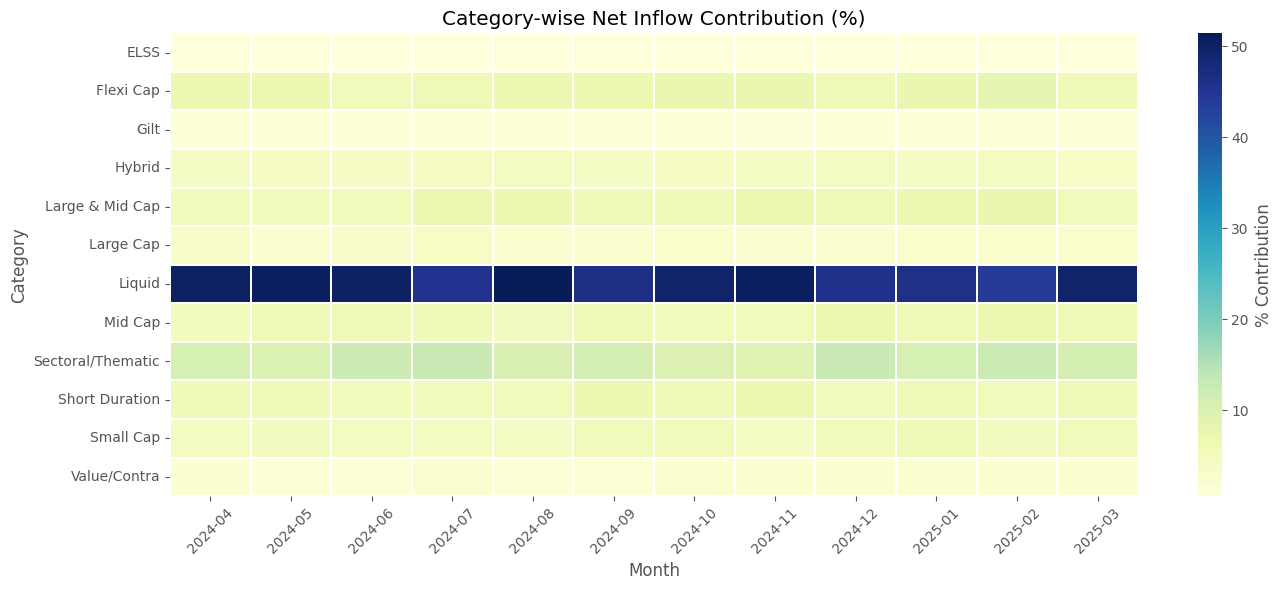

In [94]:
plt.figure(figsize=(14,6))

sns.heatmap(
    cat_pivot_norm,
    cmap="YlGnBu",
    linewidths=0.3,
    cbar_kws={'label': '% Contribution'}
)

plt.title("Category-wise Net Inflow Contribution (%)")
plt.xlabel("Month")
plt.ylabel("Category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [97]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='object')


In [98]:
print(category.head())
print(category.columns)

       month         category  net_inflow_crore
0 2024-04-01        Large Cap            2413.0
1 2024-04-01          Mid Cap            3897.0
2 2024-04-01        Small Cap            3533.0
3 2024-04-01        Flexi Cap            4947.0
4 2024-04-01  Large & Mid Cap            4214.0
Index(['month', 'category', 'net_inflow_crore'], dtype='object')


In [99]:
category["month"] = pd.to_datetime(category["month"])

In [100]:
import pandas as pd

category = pd.read_csv("../data/processed/clean_category_inflows.csv")

print(category.columns)
print(category.head())

Index(['month', 'category', 'net_inflow_crore'], dtype='object')
        month         category  net_inflow_crore
0  2024-04-01        Large Cap            2413.0
1  2024-04-01          Mid Cap            3897.0
2  2024-04-01        Small Cap            3533.0
3  2024-04-01        Flexi Cap            4947.0
4  2024-04-01  Large & Mid Cap            4214.0


In [105]:
category["month"] = pd.to_datetime(category["month"])
category["month_str"] = category["month"].dt.to_period("M").astype(str)

In [106]:
print(category.columns)
print(category.head())

Index(['month', 'category', 'net_inflow_crore', 'month_str'], dtype='object')
       month         category  net_inflow_crore month_str
0 2024-04-01        Large Cap            2413.0   2024-04
1 2024-04-01          Mid Cap            3897.0   2024-04
2 2024-04-01        Small Cap            3533.0   2024-04
3 2024-04-01        Flexi Cap            4947.0   2024-04
4 2024-04-01  Large & Mid Cap            4214.0   2024-04


In [108]:
heatmap_data = category.pivot_table(
    index="category",
    columns="month_str",
    values="net_inflow_crore",
    aggfunc="sum"
)

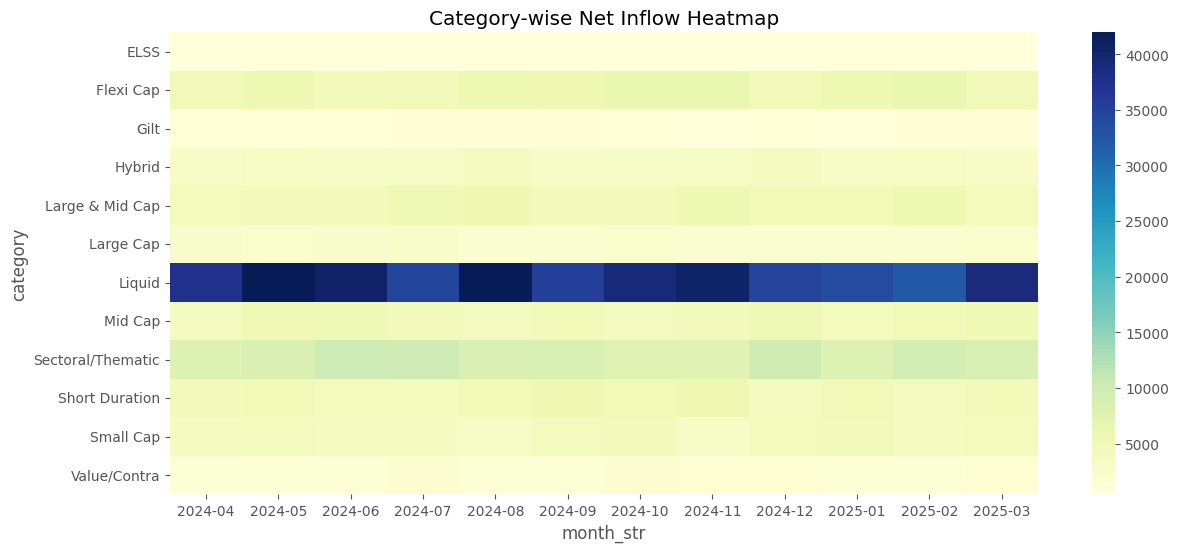

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Category-wise Net Inflow Heatmap")
plt.show()

In [ ]:
###Task 5: Investor Demographics Analysis

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
%whos

Interactive namespace is empty.


In [4]:
import pandas as pd

nav = pd.read_csv("../data/processed/clean_nav_history.csv")
fund = pd.read_csv("../data/processed/clean_fund_master.csv")
aum = pd.read_csv("../data/processed/clean_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/clean_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/clean_category_inflows.csv")
folio = pd.read_csv("../data/processed/clean_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")
investor = pd.read_csv("../data/processed/clean_investor_transactions.csv")
portfolio = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/processed/clean_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [6]:
investor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


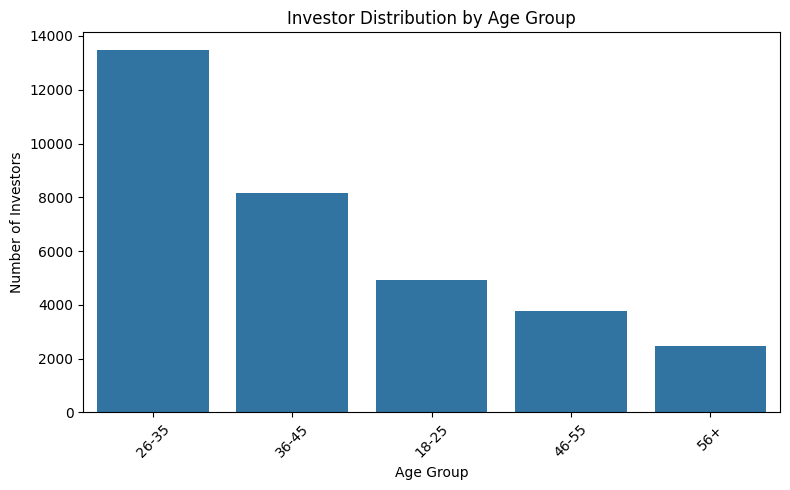

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=investor,
    x="age_group",
    order=investor["age_group"].value_counts().index
)

plt.title("Investor Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
investor["age_group"].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

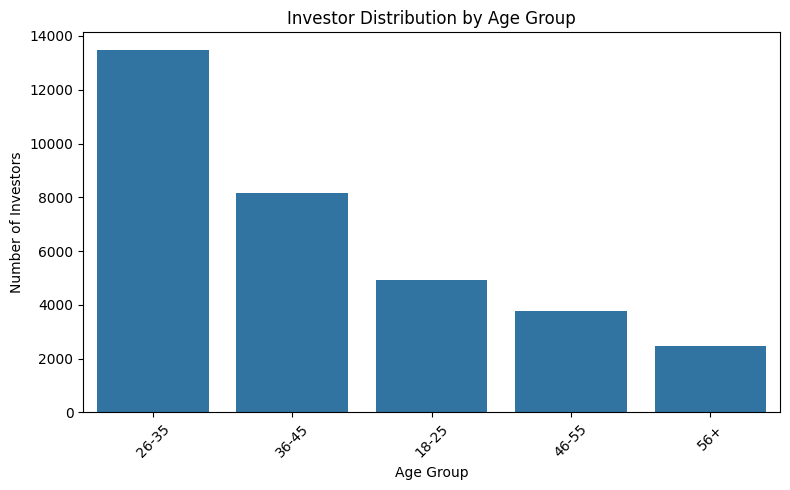

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

order = investor["age_group"].value_counts().index

sns.countplot(
    data=investor,
    x="age_group",
    order=order
)

plt.title("Investor Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [15]:
investor["gender"].value_counts()

gender
Male      21809
Female    10969
Name: count, dtype: int64

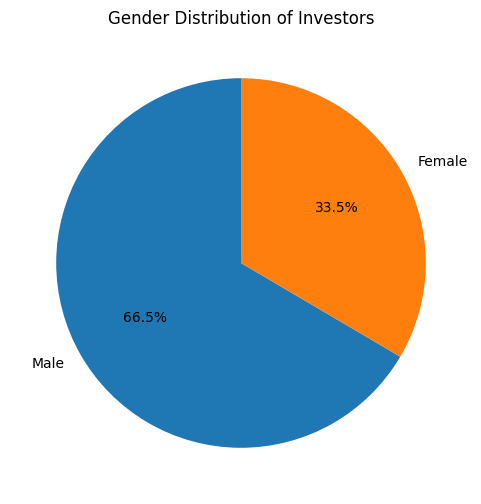

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

investor["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")
plt.ylabel("")
plt.show()

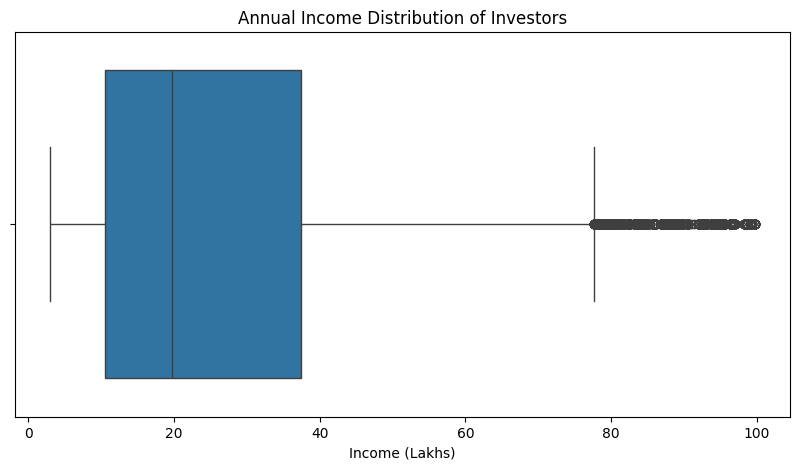

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.boxplot(
    data=investor,
    x="annual_income_lakh"
)

plt.title("Annual Income Distribution of Investors")
plt.xlabel("Income (Lakhs)")
plt.show()

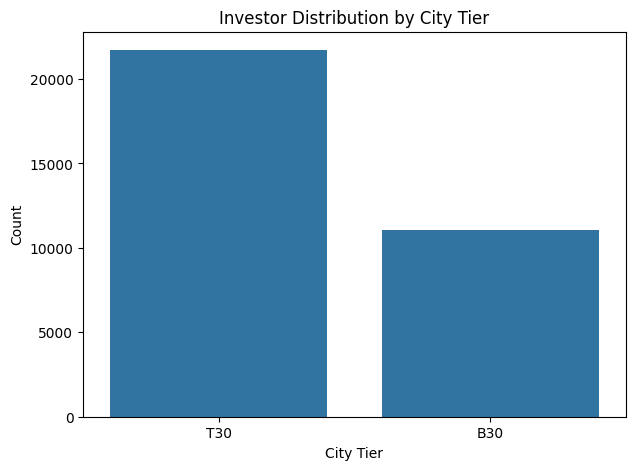

In [18]:
plt.figure(figsize=(7,5))

order = investor["city_tier"].value_counts().index

sns.countplot(
    data=investor,
    x="city_tier",
    order=order
)

plt.title("Investor Distribution by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Count")

plt.show()

In [ ]:
###FOLIO GROWTH ANALYSIS (VERY

In [19]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [20]:
folio["month"] = pd.to_datetime(folio["month"])

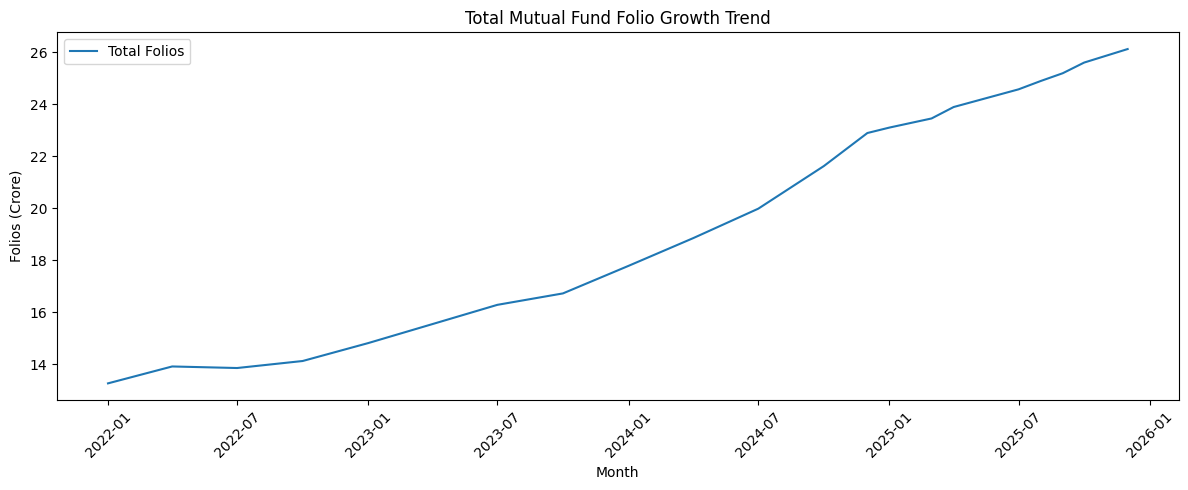

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

plt.plot(folio["month"], folio["total_folios_crore"], label="Total Folios")

plt.title("Total Mutual Fund Folio Growth Trend")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

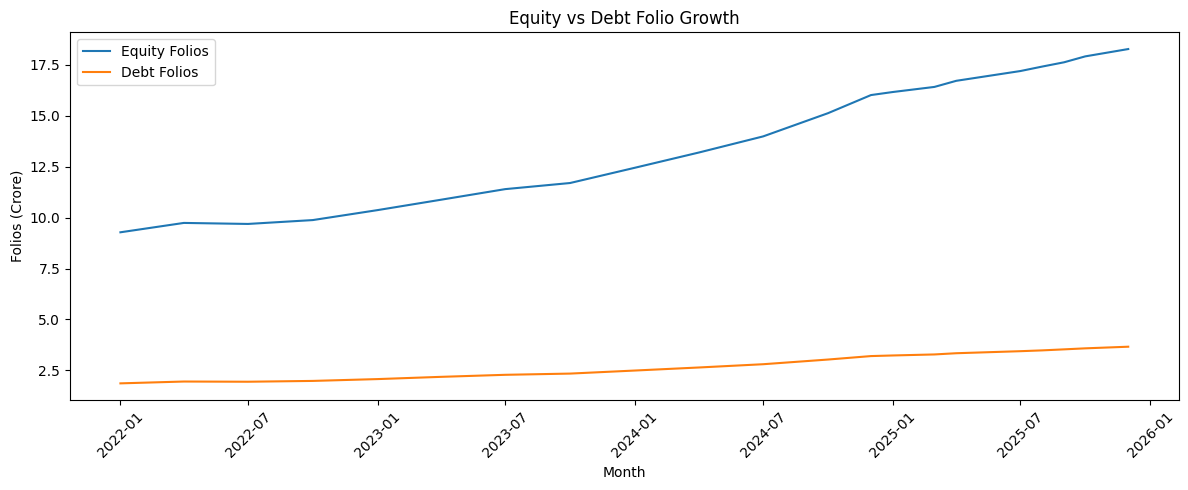

In [22]:
plt.figure(figsize=(12,5))

plt.plot(folio["month"], folio["equity_folios_crore"], label="Equity Folios")
plt.plot(folio["month"], folio["debt_folios_crore"], label="Debt Folios")

plt.title("Equity vs Debt Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
###CORRELATION MATRIX (HIGH MARKS SECTION)

<Figure size 640x480 with 0 Axes>

In [24]:
nav_sorted = nav.sort_values(["amfi_code", "date"])
nav_sorted["daily_return"] = nav_sorted.groupby("amfi_code")["nav"].pct_change()

In [25]:
fund_returns = nav_sorted.groupby("amfi_code")["daily_return"].mean().reset_index()

In [26]:
fund_corr = fund.merge(fund_returns, on="amfi_code", how="left")

In [28]:
fund_corr.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code', 'daily_return'],
      dtype='object')

In [29]:
fund_corr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
 15  daily_return        40 non-null     float64
dtypes: float64

In [30]:
fund_corr.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,daily_return
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,0.000917
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01,0.000785
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03,0.001201
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03,0.000201
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02,0.000222


In [32]:
corr_data = fund_corr.select_dtypes(include=["number"])
corr_matrix = corr_data.corr()
corr_matrix

,amfi_code,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,daily_return
amfi_code,1.000000,0.153835,0.227887,NaN,-0.116119,0.424110
expense_ratio_pct,0.153835,1.000000,0.529036,NaN,-0.368232,0.426593
exit_load_pct,0.227887,0.529036,1.000000,NaN,-0.551698,0.416318
min_sip_amount,NaN,NaN,NaN,NaN,NaN,NaN
min_lumpsum_amount,-0.116119,-0.368232,-0.551698,NaN,1.000000,-0.305523
daily_return,0.424110,0.426593,0.416318,NaN,-0.305523,1.000000


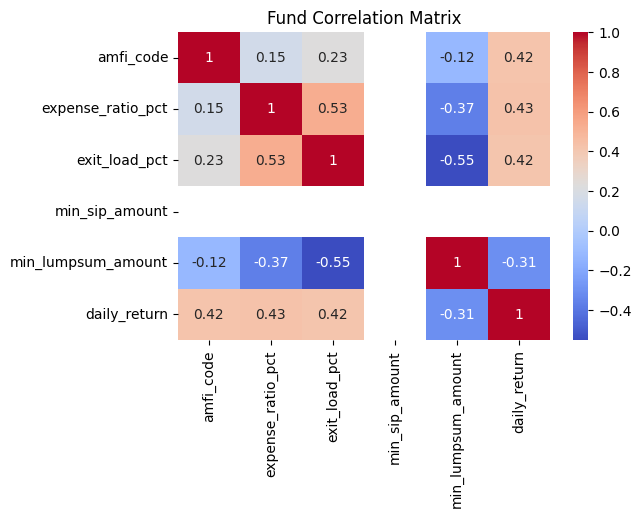

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Fund Correlation Matrix")
plt.show()

In [34]:
sip["month"] = pd.to_datetime(sip["month"])

In [36]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="SIP Trend Over Time"
)
fig.show()

In [38]:
fig.add_annotation(
    x=sip["month"].max(),
    y=sip["sip_inflow_crore"].max(),
    text="Peak SIP Inflow",
    showarrow=True
)

In [39]:
import os
os.makedirs("charts", exist_ok=True)

fig.write_html("charts/sip_trend.html")

In [40]:
category["month"] = pd.to_datetime(category["month"]).dt.to_period("M").astype(str)

In [42]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='object')


In [43]:
category.columns = category.columns.str.strip()

In [45]:
print(category.columns)
print(category.head())

Index(['month', 'category', 'net_inflow_crore'], dtype='object')
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


In [46]:
category = category.copy()

# clean column names
category.columns = category.columns.str.strip()

# recreate month_str safely (IMPORTANT)
category["month_str"] = pd.to_datetime(category["month"]).dt.to_period("M").astype(str)

In [47]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore', 'month_str'], dtype='object')


In [48]:
heatmap_data = category.pivot_table(
    index="category",
    columns="month_str",
    values="net_inflow_crore",
    aggfunc="sum"
)

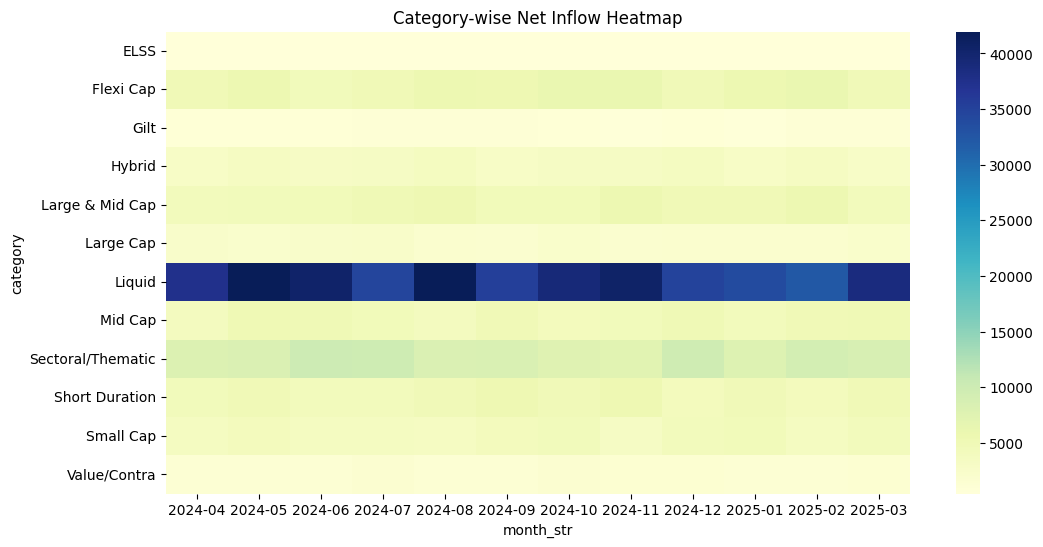

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Category-wise Net Inflow Heatmap")
plt.show()

In [50]:
print(portfolio.columns)
portfolio.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [ ]:
###Task 8: Sector Allocation Donut Chart

In [51]:
sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

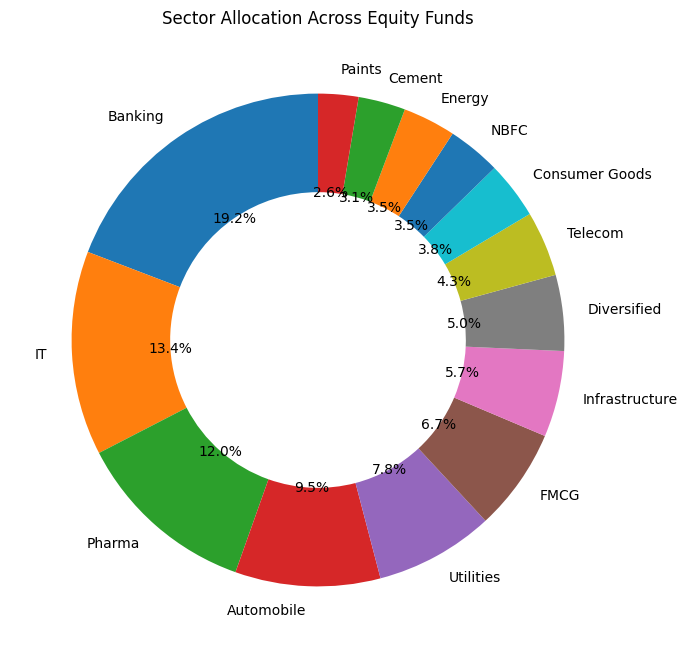

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Sector Allocation Across Equity Funds")
plt.show()

In [53]:
import os

os.makedirs("charts", exist_ok=True)

plt.savefig(
    "charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

print("Sector Allocation chart saved!")

Sector Allocation chart saved!


<Figure size 640x480 with 0 Axes>

In [ ]:
###Task 9 — NAV Return Correlation Matrix

In [55]:
nav_fund = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_fund.shape)
nav_fund.head()

(46000, 4)


,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [56]:
import pandas as pd

nav = pd.read_csv("../data/processed/clean_nav_history.csv")
fund = pd.read_csv("../data/processed/clean_fund_master.csv")

In [57]:
nav["date"] = pd.to_datetime(nav["date"])

In [58]:
nav_fund.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [59]:
nav_fund = nav_fund.sort_values(["scheme_name", "date"])

In [60]:
nav_fund["daily_return"] = (
    nav_fund.groupby("scheme_name")["nav"]
    .pct_change()
)

In [61]:
nav_fund.head()

,amfi_code,date,nav,scheme_name,daily_return
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314


In [62]:
selected_funds = nav_fund["scheme_name"].unique()[:10]

selected_funds

array(['ABSL Frontline Equity Fund - Regular - Growth',
       'ABSL Liquid Fund - Regular - Growth',
       'ABSL Small Cap Fund - Regular - Growth',
       'Axis Bluechip Fund - Direct - Growth',
       'Axis Bluechip Fund - Regular - Growth',
       'Axis Midcap Fund - Regular - Growth',
       'Axis Small Cap Fund - Regular - Growth',
       'DSP Midcap Fund - Regular - Growth',
       'DSP Small Cap Fund - Regular - Growth',
       'DSP Top 100 Equity Fund - Regular - Growth'], dtype=object)

In [63]:
corr_df = nav_fund[
    nav_fund["scheme_name"].isin(selected_funds)
]

corr_df = corr_df.pivot(
    index="date",
    columns="scheme_name",
    values="daily_return"
)

corr_df.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,0.001153,-0.000141,-0.010865,-0.000187,-0.006561,-0.003597,0.018757,0.000482,-0.010498,-0.008592
2022-01-05,0.003866,0.000382,0.000603,-0.002863,-0.007511,0.016595,0.019898,0.008670,-0.002593,-0.006480
2022-01-06,-0.002128,-0.000143,-0.029101,-0.009811,0.009926,-0.000246,-0.000431,-0.013861,-0.008382,-0.003818
2022-01-07,-0.006314,0.000215,0.024766,0.008215,0.009331,-0.018524,0.032482,0.004317,0.011680,-0.004069


In [64]:
corr_matrix = corr_df.corr()

corr_matrix

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.000000,-0.027230,0.010202,0.012036,0.056952,-0.040309,-0.029799,-0.000607,-0.004785,0.021622
ABSL Liquid Fund - Regular - Growth,-0.027230,1.000000,-0.007530,-0.038607,-0.029781,0.010877,0.039690,0.027775,-0.010105,0.020234
ABSL Small Cap Fund - Regular - Growth,0.010202,-0.007530,1.000000,0.056726,0.013961,0.017462,-0.029528,0.011435,-0.006471,0.020669
Axis Bluechip Fund - Direct - Growth,0.012036,-0.038607,0.056726,1.000000,-0.003216,0.030734,-0.009111,0.016425,0.017761,0.006239
Axis Bluechip Fund - Regular - Growth,0.056952,-0.029781,0.013961,-0.003216,1.000000,0.015815,0.037383,-0.023655,0.013288,0.018544
Axis Midcap Fund - Regular - Growth,-0.040309,0.010877,0.017462,0.030734,0.015815,1.000000,-0.011836,-0.020921,-0.017765,0.036254
Axis Small Cap Fund - Regular - Growth,-0.029799,0.039690,-0.029528,-0.009111,0.037383,-0.011836,1.000000,-0.012415,-0.000828,0.025630
DSP Midcap Fund - Regular - Growth,-0.000607,0.027775,0.011435,0.016425,-0.023655,-0.020921,-0.012415,1.000000,0.007160,-0.029903
DSP Small Cap Fund - Regular - Growth,-0.004785,-0.010105,-0.006471,0.017761,0.013288,-0.017765,-0.000828,0.007160,1.000000,0.003233


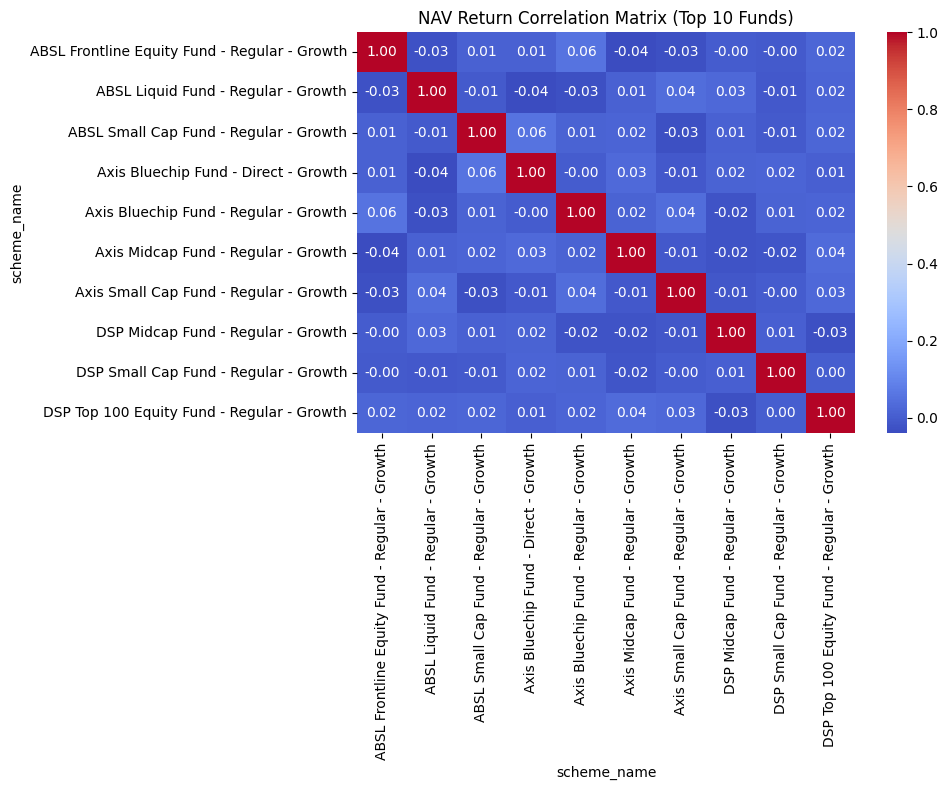

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix (Top 10 Funds)")
plt.tight_layout()
plt.show()

In [66]:
import os

os.makedirs("charts", exist_ok=True)

plt.savefig(
    "charts/nav_return_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

print("Correlation heatmap saved!")

Correlation heatmap saved!


<Figure size 640x480 with 0 Axes>

# 📌 Day 3 – EDA Findings

## 1. NAV Growth

The selected mutual funds showed a steady increase in Net Asset Value (NAV) over the observed period, indicating long-term growth with normal market fluctuations.

## 2. Assets Under Management (AUM)

The total Assets Under Management increased consistently, reflecting growing investor confidence and higher capital inflows into mutual funds.

## 3. SIP Trends

Monthly SIP inflows exhibited an overall upward trend, reaching the highest level in the latest months, indicating increasing retail participation.

## 4. Category-wise Inflows

The category heatmap showed that Liquid Funds and Equity-oriented categories received higher inflows than most other categories during the study period.

## 5. Investor Age Distribution

The 26–35 age group formed the largest investor segment, followed by the 36–45 age group, showing that young and middle-aged investors dominate mutual fund investments.

## 6. Gender Distribution

The gender distribution indicates that male investors constitute a larger share of the investor base, while female participation is also significant.

## 7. Geographic Distribution

Tier-1 and Tier-2 cities contributed the majority of mutual fund investments, indicating stronger participation from urban regions.

## 8. Folio Growth

Equity folios showed faster and more consistent growth than debt folios, suggesting increasing investor preference for equity mutual funds.

## 9. Sector Allocation

The sector allocation analysis revealed that Banking, Utilities, Pharma, and Diversified sectors account for a substantial share of portfolio holdings, demonstrating diversification across industries.

## 10. NAV Return Correlation

The correlation matrix showed varying levels of correlation among the selected funds. Funds within similar investment categories generally exhibited stronger positive correlations than funds from different categories.


In [3]:
import os
print(os.getcwd())

c:\Users\Hp\MutualFundAnalytics\notebooks


In [4]:
import os

os.listdir("../data")

['processed', 'raw']

In [5]:
import pandas as pd

nav = pd.read_csv("../data/processed/clean_nav_history.csv")
fund = pd.read_csv("../data/processed/clean_fund_master.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [6]:
nav["date"] = pd.to_datetime(nav["date"])

In [7]:
nav_fund = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_fund.shape)
nav_fund.head()

(46000, 4)


,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [2]:
nav.head()

NameError: name 'nav' is not defined

In [1]:
nav_fund.head()

NameError: name 'nav_fund' is not defined